Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx
(7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month

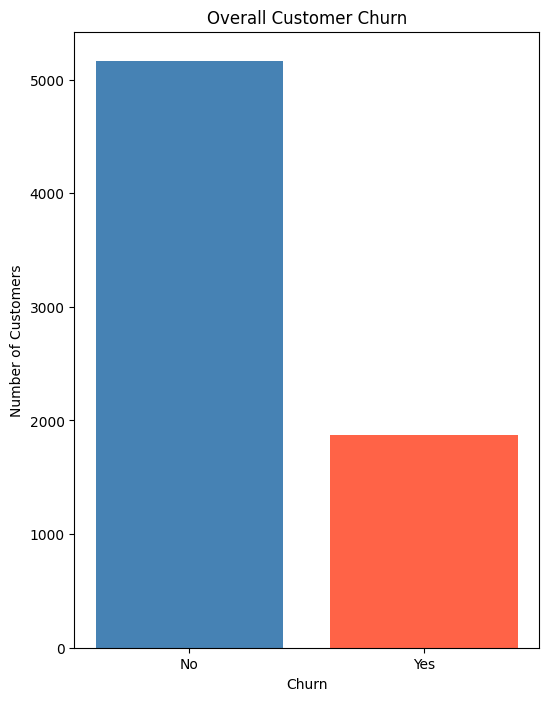

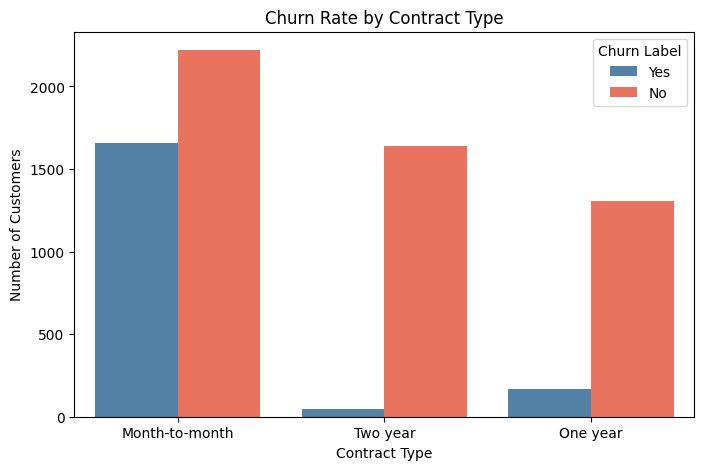

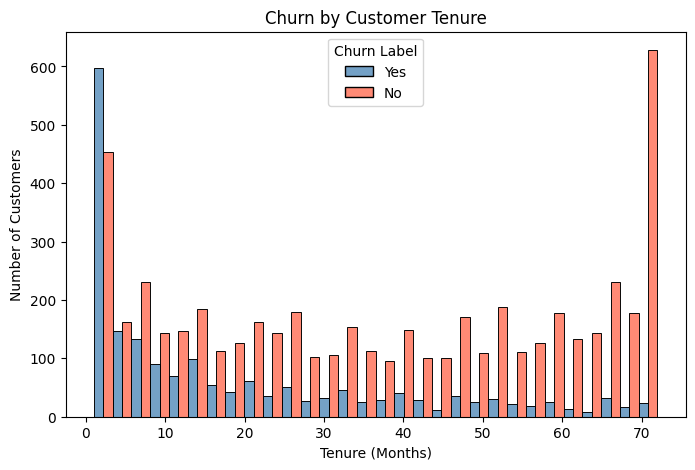

/tmp/ipykernel_1614/1062868968.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y='Monthly Charges',


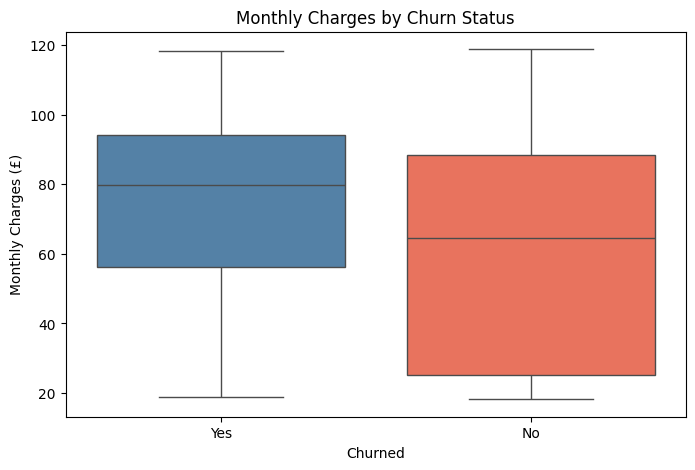

Churn Label
0    5163
1    1869
Name: count, dtype: int64
   Churn Label  Partner  Dependents  Phone Service  Paperless Billing  \
0            1        0           0              1                  1   
1            1        0           1              1                  1   
2            1        0           1              1                  1   
3            1        1           1              1                  1   
4            1        0           1              1                  1   

   Senior Citizen  
0               0  
1               0  
2               0  
3               0  
4               0  
(7032, 37)
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'Churn Lab

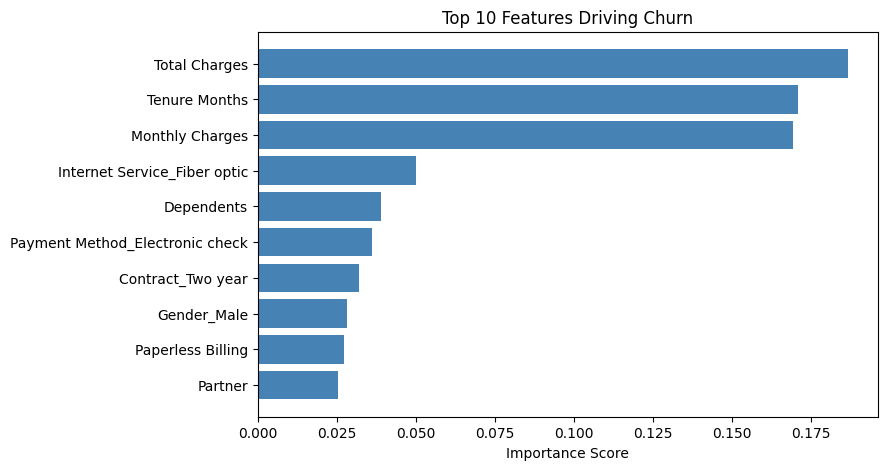

                            feature  importance
14                    Total Charges    0.186863
3                     Tenure Months    0.171007
13                  Monthly Charges    0.169526
20     Internet Service_Fiber optic    0.050051
2                        Dependents    0.039091
18  Payment Method_Electronic check    0.036342
16                Contract_Two year    0.032215
22                      Gender_Male    0.028190
12                Paperless Billing    0.027233
1                           Partner    0.025500


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

from google.colab import files
uploaded = files.upload()

df = pd.read_excel('Telco_customer_churn.xlsx')
print(df.shape)
print(df.head())
print(df.dtypes)

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(df['Total Charges'].isnull().sum())
df = df.dropna(subset=['Total Charges'])
print(df['Total Charges'].isnull().sum())
print(df['Total Charges'].dtype)
print(df.shape)

print(df.isnull().sum())
print(df.duplicated().sum())
print(df['Churn Label'].value_counts())
print(df['Contract'].value_counts())
print(df['Payment Method'].value_counts())

# Overall Churn rate
churn_count = df['Churn Label'].value_counts()
plt.figure(figsize=(6, 8))
plt.bar(churn_count.index, churn_count.values, color=['steelblue', 'tomato'])
plt.title('Overall Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# Chart 2 - Churn by contract type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn Label', palette=['steelblue','tomato'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

# Chart 3 - Tenure vs Churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Tenure Months', hue='Churn Label',
             palette=['steelblue','tomato'], bins=30, multiple='dodge')
plt.title('Churn by Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

# Chart 4 - Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges',
            palette=['steelblue','tomato'])
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churned')
plt.ylabel('Monthly Charges (£)')
plt.show()

# Stage 4 - Encode binary columns
binary_cols = ['Churn Label', 'Partner', 'Dependents',
               'Phone Service', 'Paperless Billing',
               'Senior Citizen']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

remaining_binary = ['Multiple Lines', 'Online Security', 'Online Backup',
                    'Device Protection', 'Tech Support',
                    'Streaming TV', 'Streaming Movies']

for col in remaining_binary:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No internet service': 0,
                           'No phone service': 0})

print(df['Churn Label'].value_counts())
print(df[binary_cols].head())

# One-hot encode categorical columns
cat_cols = ['Contract', 'Payment Method',
            'Internet Service', 'Gender']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(df.shape)
print(df.columns.tolist())

# Select features and target
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City',
             'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
             'Churn Reason', 'Churn Score', 'Churn Value', 'CLTV']

X = df.drop(columns=drop_cols + ['Churn Label'])
y = df['Churn Label']

print(X.shape)
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Find remaining object columns in X_train
print(X_train.dtypes[X_train.dtypes == 'object'])
print(df['Senior Citizen'].value_counts())

# Training the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

# Evaluate the model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.2%}")
print(f"ROC-AUC: {roc_auc:.2f}")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(feature_importance['feature'],
         feature_importance['importance'],
         color='steelblue')
plt.title('Top 10 Features Driving Churn')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance)